In [ ]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.gridspec import GridSpec
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
from scipy.stats import boxcox, normaltest, shapiro
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

try:
    from pmdarima import auto_arima
except ImportError:
    pass

try:
    from prophet import Prophet
except ImportError:
    pass

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import itertools
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize']  = (14, 5)
plt.rcParams['axes.grid']       = True
plt.rcParams['grid.alpha']      = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid', palette='muted')


In [ ]:
# Load the dataset

df_raw = pd.read_csv('/content/sample_data/employee_data.csv')

# 2. Convert ExitDate to datetime
df_raw['ExitDate'] = pd.to_datetime(df_raw['ExitDate'], errors='coerce', dayfirst=True)

print(f"Dataset shape: {df_raw.shape}")
print(f"Columns      : {df_raw.columns.tolist()}")

# Display the first and last rows
print("\n--- First 5 Rows ---")
display(df_raw.head(5))

print("\n--- Last 5 Rows ---")
display(df_raw.tail(5))

Dataset shape: (3000, 26)
Columns      : ['EmpID', 'FirstName', 'LastName', 'StartDate', 'ExitDate', 'Title', 'Supervisor', 'ADEmail', 'BusinessUnit', 'EmployeeStatus', 'EmployeeType', 'PayZone', 'EmployeeClassificationType', 'TerminationType', 'TerminationDescription', 'DepartmentType', 'Division', 'DOB', 'State', 'JobFunctionDescription', 'GenderCode', 'LocationCode', 'RaceDesc', 'MaritalDesc', 'Performance Score', 'Current Employee Rating']

--- First 5 Rows ---


,EmpID,FirstName,LastName,StartDate,ExitDate,Title,Supervisor,ADEmail,BusinessUnit,EmployeeStatus,...,Division,DOB,State,JobFunctionDescription,GenderCode,LocationCode,RaceDesc,MaritalDesc,Performance Score,Current Employee Rating
0,3427,Uriah,Bridges,20-Sep-19,NaT,Production Technician I,Peter Oneill,uriah.bridges@bilearner.com,CCDR,Active,...,Finance & Accounting,07-10-1969,MA,Accounting,Female,34904,White,Widowed,Fully Meets,4
1,3428,Paula,Small,11-Feb-23,NaT,Production Technician I,Renee Mccormick,paula.small@bilearner.com,EW,Active,...,Aerial,30-08-1965,MA,Labor,Male,6593,Hispanic,Widowed,Fully Meets,3
2,3429,Edward,Buck,10-Dec-18,NaT,Area Sales Manager,Crystal Walker,edward.buck@bilearner.com,PL,Active,...,General - Sga,06-10-1991,MA,Assistant,Male,2330,Hispanic,Widowed,Fully Meets,4
3,3430,Michael,Riordan,21-Jun-21,NaT,Area Sales Manager,Rebekah Wright,michael.riordan@bilearner.com,CCDR,Active,...,Finance & Accounting,04-04-1998,ND,Clerk,Male,58782,Other,Single,Fully Meets,2
4,3431,Jasmine,Onque,29-Jun-19,NaT,Area Sales Manager,Jason Kim,jasmine.onque@bilearner.com,TNS,Active,...,General - Con,29-08-1969,FL,Laborer,Female,33174,Other,Married,Fully Meets,3



--- Last 5 Rows ---


,EmpID,FirstName,LastName,StartDate,ExitDate,Title,Supervisor,ADEmail,BusinessUnit,EmployeeStatus,...,Division,DOB,State,JobFunctionDescription,GenderCode,LocationCode,RaceDesc,MaritalDesc,Performance Score,Current Employee Rating
2995,3422,Jakobe,Erickson,22-Jun-22,2022-08-07,Production Technician I,Bethany Carter,jakobe.erickson@bilearner.com,PYZ,Leave of Absence,...,Engineers,23-06-1998,MA,Model Assistant,Female,44500,Other,Widowed,Fully Meets,3
2996,3423,Adyson,Strickland,28-Dec-20,NaT,Production Technician I,Caroline Harris,adyson.strickland@bilearner.com,SVG,Active,...,Engineers,10-06-2001,MA,Engineer,Male,35444,Black,Widowed,Fully Meets,3
2997,3424,Annabel,Wilkins,09-Dec-20,2022-08-04,Production Technician I,Mr. James Castillo,annabel.wilkins@bilearner.com,TNS,Voluntarily Terminated,...,Wireline Construction,27-01-1997,MA,Laborer,Male,6608,White,Single,Fully Meets,2
2998,3425,Kendra,Braun,28-May-19,2021-10-23,Production Technician I,Michael Woods,kendra.braun@bilearner.com,WBL,Voluntarily Terminated,...,Aerial,28-05-1954,MA,Foreman,Female,3807,Hispanic,Divorced,Fully Meets,2
2999,3426,Chace,Kerr,27-Apr-22,NaT,Production Technician I,Javier Mccall,chace.kerr@bilearner.com,BPC,Active,...,Field Operations,11-09-1990,MA,Warehouse Technician,Female,57487,White,Married,Fully Meets,2


In [ ]:
# Initial Structural Inspection

# Data types and memory usage
print("=" * 55)
print(" DATA TYPES & NON-NULL COUNTS")
print("=" * 55)
# Ensure you use df_raw (from your previous step) or df
print(df_raw.info())

# Shape
print(f"\nRows: {df_raw.shape[0]:,}  |  Columns: {df_raw.shape[1]}")

# Duplicated rows
print(f"Duplicate rows: {df_raw.duplicated().sum()}")

# Date and target column
DATE_COLUMN   = 'ExitDate'
TARGET_COLUMN = 'TurnoverCount'

print(f"\nDate column   : '{DATE_COLUMN}'")
print(f"Target column : '{TARGET_COLUMN}'")

 DATA TYPES & NON-NULL COUNTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   EmpID                       3000 non-null   int64         
 1   FirstName                   3000 non-null   object        
 2   LastName                    3000 non-null   object        
 3   StartDate                   3000 non-null   object        
 4   ExitDate                    1533 non-null   datetime64[ns]
 5   Title                       3000 non-null   object        
 6   Supervisor                  3000 non-null   object        
 7   ADEmail                     3000 non-null   object        
 8   BusinessUnit                3000 non-null   object        
 9   EmployeeStatus              3000 non-null   object        
 10  EmployeeType                3000 non-null   object        
 11  PayZone                   

In [ ]:
# Descriptive Statistics

# Create the Time Series DataFrame
df_exits = df_raw[df_raw['ExitDate'].notnull()].copy()
df_ts = df_exits.set_index('ExitDate').resample('M').size().reset_index()
df_ts.columns = ['ExitDate', 'TurnoverCount']

# Full descriptive statistics
print("=" * 55)
print(" DESCRIPTIVE STATISTICS (Monthly Turnover)")
print("=" * 55)

display(df_ts.describe().T)

# Additional central tendency and dispersion for target
target_raw = df_ts[TARGET_COLUMN].dropna()

print(f"\nTarget Variable Summary: '{TARGET_COLUMN}'")
print(f"  Mean              : {target_raw.mean():.4f}")
print(f"  Median            : {target_raw.median():.4f}")
print(f"  Std Dev           : {target_raw.std():.4f}")
print(f"  Coefficient of Var: {target_raw.std() / target_raw.mean() * 100:.2f}%")
print(f"  Skewness          : {target_raw.skew():.4f}")
print(f"  Kurtosis          : {target_raw.kurt():.4f}")
print(f"  Min               : {target_raw.min():.4f}")
print(f"  Max               : {target_raw.max():.4f}")

 DESCRIPTIVE STATISTICS (Monthly Turnover)


,count,mean,min,25%,50%,75%,max,std
ExitDate,58,2021-04-15 09:31:02.068965632,2018-11-30 00:00:00,2020-02-07 06:00:00,2021-04-15 00:00:00,2022-06-22 12:00:00,2023-08-31 00:00:00,NaN
TurnoverCount,58.0,26.431034,2.0,8.25,19.5,36.25,127.0,26.06006



Target Variable Summary: 'TurnoverCount'
  Mean              : 26.4310
  Median            : 19.5000
  Std Dev           : 26.0601
  Coefficient of Var: 98.60%
  Skewness          : 1.7894
  Kurtosis          : 3.7129
  Min               : 2.0000
  Max               : 127.0000


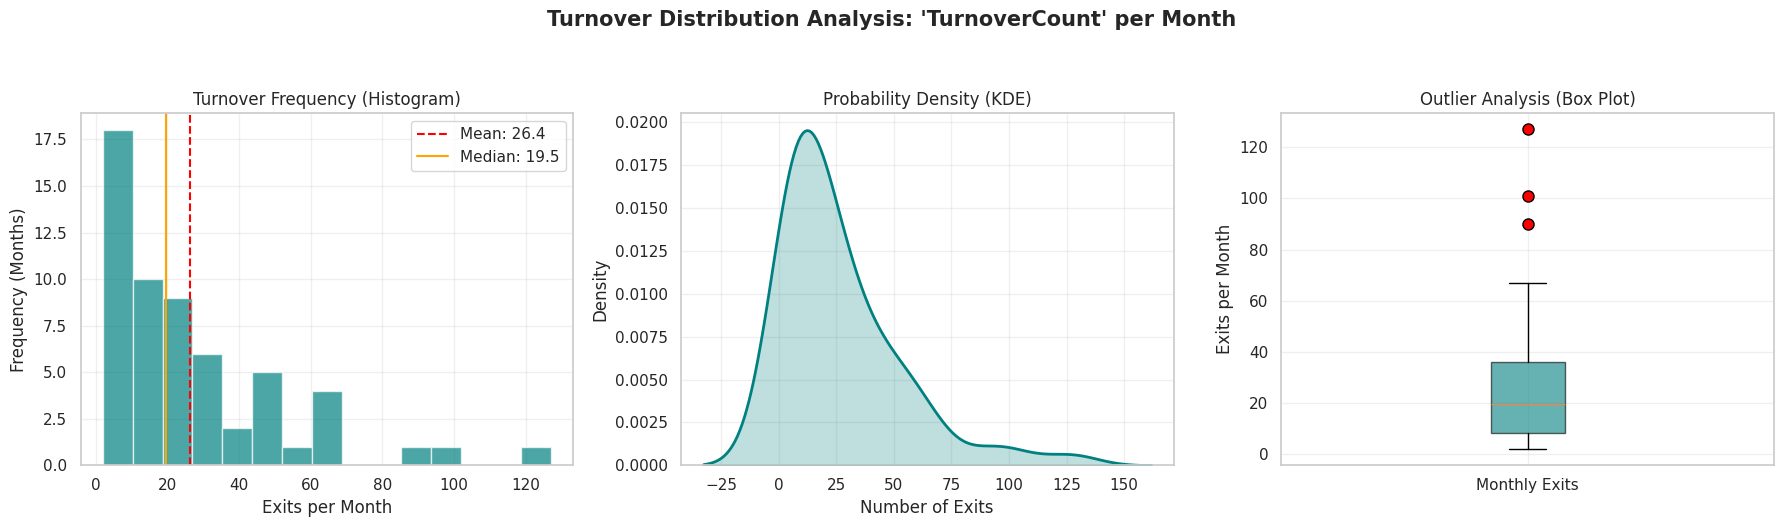

In [ ]:
# Visual Exploratory Data Analysis

target_raw = df_ts[TARGET_COLUMN]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Turnover Distribution Analysis: '{TARGET_COLUMN}' per Month",
             fontsize=15, fontweight='bold', y=1.05)

# 1. Histogram
axes[0].hist(target_raw, bins=15, color='#800000', edgecolor='white', alpha=0.7)
axes[0].axvline(target_raw.mean(), color='red', linestyle='--', label=f'Mean: {target_raw.mean():.1f}')
axes[0].axvline(target_raw.median(), color='orange', linestyle='-', label=f'Median: {target_raw.median():.1f}')
axes[0].set_title('Turnover Frequency (Histogram)', fontsize=12)
axes[0].set_xlabel('Exits per Month')
axes[0].set_ylabel('Frequency (Months)')
axes[0].legend()

# 2. KDE
sns.kdeplot(target_raw, ax=axes[1], fill=True, color='teal', linewidth=2)
axes[1].set_title('Probability Density (KDE)', fontsize=12)
axes[1].set_xlabel('Number of Exits')

# 3. Box plot
axes[2].boxplot(target_raw, vert=True, patch_artist=True,
                boxprops=dict(facecolor='teal', alpha=0.6),
                flierprops=dict(marker='o', markerfacecolor='red', markersize=8))
axes[2].set_title('Outlier Analysis (Box Plot)', fontsize=12)
axes[2].set_ylabel('Exits per Month')
axes[2].set_xticklabels(['Monthly Exits'])

plt.tight_layout()
plt.show()

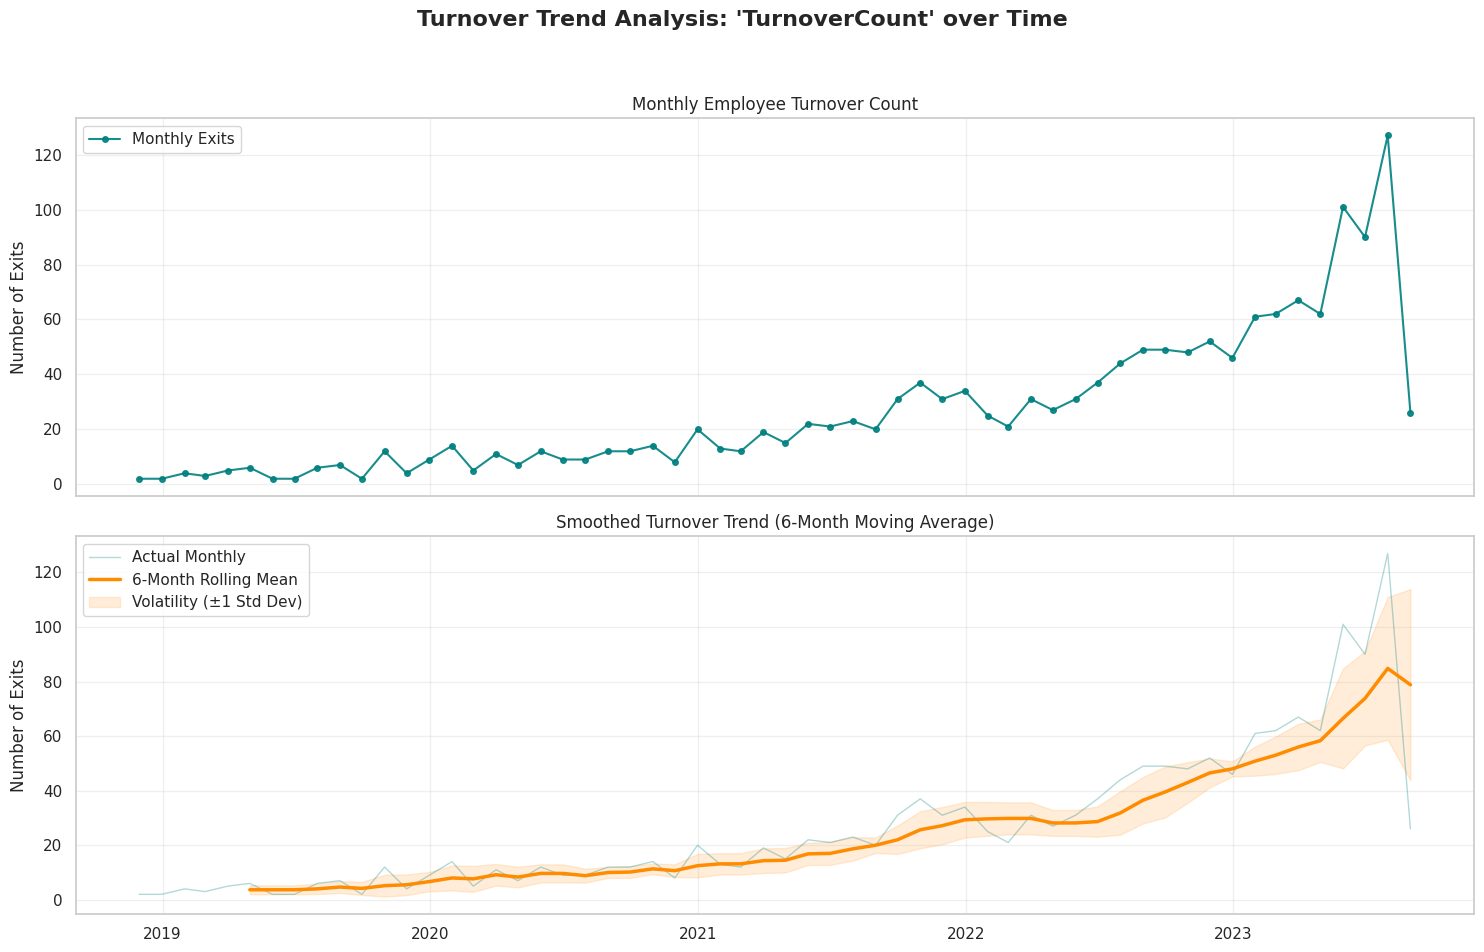

In [ ]:
df_preview = df_ts.copy()
df_preview = df_preview.sort_values('ExitDate')

# Window for rolling stats
WINDOW = 6

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
fig.suptitle(f"Turnover Trend Analysis: '{TARGET_COLUMN}' over Time",
             fontsize=16, fontweight='bold')

# 1. Raw Series (Monthly Exits)
axes[0].plot(df_preview['ExitDate'], df_preview['TurnoverCount'],
             color='teal', marker='o', markersize=4, linewidth=1.5, alpha=0.9, label='Monthly Exits')
axes[0].set_ylabel('Number of Exits')
axes[0].set_title('Monthly Employee Turnover Count')
axes[0].legend()

# 2. Rolling Statistics (Smoothing the Trend)
rolling_mean = df_preview['TurnoverCount'].rolling(window=WINDOW).mean()
rolling_std  = df_preview['TurnoverCount'].rolling(window=WINDOW).std()

axes[1].plot(df_preview['ExitDate'], df_preview['TurnoverCount'],
             color='teal', linewidth=1, alpha=0.3, label='Actual Monthly')
axes[1].plot(df_preview['ExitDate'], rolling_mean,
             color='darkorange', linewidth=2.5, label=f'{WINDOW}-Month Rolling Mean')

# Shaded area for volatility (Standard Deviation)
axes[1].fill_between(df_preview['ExitDate'],
                     rolling_mean - rolling_std,
                     rolling_mean + rolling_std,
                     color='darkorange', alpha=0.15, label='Volatility (±1 Std Dev)')

axes[1].set_ylabel('Number of Exits')
axes[1].set_title(f'Smoothed Turnover Trend ({WINDOW}-Month Moving Average)')
axes[1].legend()

# Formatting X-axis dates
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# Datetime Parsing, Indexing & Resampling

df_prep = df_raw.copy()

# Parse the ExitDate
df_prep[DATE_COLUMN] = pd.to_datetime(df_prep[DATE_COLUMN], dayfirst=True, errors='coerce')

# Filter for employees who have actually left
df_exits_only = df_prep.dropna(subset=[DATE_COLUMN])

# Sort chronologically
df_exits_only = df_exits_only.sort_values(DATE_COLUMN).reset_index(drop=True)

# Set datetime as index
df_exits_only = df_exits_only.set_index(DATE_COLUMN)

# Resample to chosen frequency
FREQ = 'M'

ts = df_exits_only.resample(FREQ).size().to_frame(name=TARGET_COLUMN)

# Handle missing periods
ts = ts.asfreq(FREQ, fill_value=0)

print(f"Time series frequency : {FREQ}")
print(f"Number of periods     : {len(ts)}")
print(f"Start date            : {ts.index.min().date()}")
print(f"End date              : {ts.index.max().date()}")
print(f"Total Exits Counted   : {ts[TARGET_COLUMN].sum()}")

print("\n--- Processed Monthly Turnover Series ---")
display(ts.tail(10))

Time series frequency : M
Number of periods     : 58
Start date            : 2018-11-30
End date              : 2023-08-31
Total Exits Counted   : 1533

--- Processed Monthly Turnover Series ---


,TurnoverCount
ExitDate,
2022-11-30,52
2022-12-31,46
2023-01-31,61
2023-02-28,62
2023-03-31,67
2023-04-30,62
2023-05-31,101
2023-06-30,90
2023-07-31,127


In [ ]:
# Missing Value Detection & Treatment

# Check for NaN values
missing_count = ts[TARGET_COLUMN].isna().sum()
missing_pct   = missing_count / len(ts) * 100
print(f"Missing values: {missing_count} ({missing_pct:.2f}%)")

# Check for implicit gaps (Missing months in the timeline)
full_idx      = pd.date_range(start=ts.index.min(), end=ts.index.max(), freq=FREQ)
missing_dates = full_idx.difference(ts.index)
print(f"Implicit gap periods : {len(missing_dates)}")

# Reindex to ensure a complete, gapless index
ts = ts.reindex(full_idx)

# Treatment
ts[TARGET_COLUMN] = ts[TARGET_COLUMN].fillna(0)


ts['Turnover_Interpolated'] = ts[TARGET_COLUMN].interpolate(method='linear')

print(f"\nMissing values after treatment: {ts[TARGET_COLUMN].isna().sum()}")
print("✅ Missing value treatment complete (Gap-filled with 0).")

Missing values: 0 (0.00%)
Implicit gap periods : 0

Missing values after treatment: 0
✅ Missing value treatment complete (Gap-filled with 0).


IQR method    — outliers detected: 3
Z-score (>3σ) — outliers detected: 1

IQR Bounds for Turnover: lower=-33.75, upper=78.25


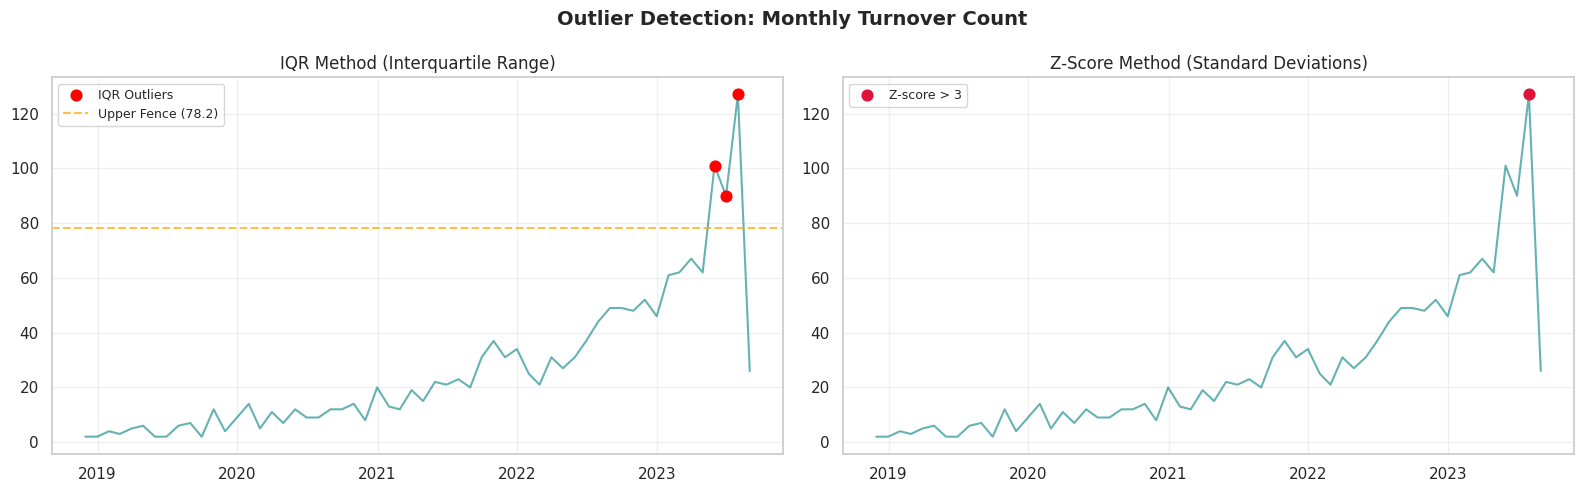

✅ Clipping Complete.
Maximum value reduced from 127.00 to 78.25
✂️ Dropped the last row. New end date: 2023-07-31
Total months for analysis: 57
✅ Outlier analysis complete.


In [ ]:
# Outlier Detection & Treatment

# Calculate IQR for the TurnoverCount
Q1 = ts[TARGET_COLUMN].quantile(0.25)
Q3 = ts[TARGET_COLUMN].quantile(0.75)
IQR = Q3 - Q1

lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR

# Identify Outliers
outliers_iqr = ts[ts[TARGET_COLUMN] > upper_iqr] # Lower outliers are rare in turnover

# Z-score-based outlier detection
z_scores = np.abs(stats.zscore(ts[TARGET_COLUMN]))
outliers_z = ts[z_scores > 3]

print(f"IQR method    — outliers detected: {len(outliers_iqr)}")
print(f"Z-score (>3σ) — outliers detected: {len(outliers_z)}")
print(f"\nIQR Bounds for Turnover: lower={lower_iqr:.2f}, upper={upper_iqr:.2f}")

# Visualize outliers
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Outlier Detection: Monthly Turnover Count', fontsize=14, fontweight='bold')

# IQR Plot
axes[0].plot(ts.index, ts[TARGET_COLUMN], color='teal', linewidth=1.5, alpha=0.6)
axes[0].scatter(outliers_iqr.index, outliers_iqr[TARGET_COLUMN],
                color='red', zorder=5, s=60, label='IQR Outliers')
axes[0].axhline(upper_iqr, color='orange', linestyle='--', alpha=0.7, label=f'Upper Fence ({upper_iqr:.1f})')
axes[0].set_title('IQR Method (Interquartile Range)')
axes[0].legend(fontsize=9)

# Z-Score Plot
axes[1].plot(ts.index, ts[TARGET_COLUMN], color='teal', linewidth=1.5, alpha=0.6)
axes[1].scatter(outliers_z.index, outliers_z[TARGET_COLUMN],
                color='crimson', zorder=5, s=60, label='Z-score > 3')
axes[1].set_title('Z-Score Method (Standard Deviations)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


# Treatment
# Create a copy to keep the original data intact
ts_cleaned = ts.copy()

# Winsorization/Clipping of outliers
ts_cleaned[TARGET_COLUMN] = ts_cleaned[TARGET_COLUMN].clip(lower=lower_iqr, upper=upper_iqr)

print(f"✅ Clipping Complete.")
print(f"Maximum value reduced from {ts[TARGET_COLUMN].max():.2f} to {ts_cleaned[TARGET_COLUMN].max():.2f}")

ts_final = ts_cleaned.copy()

# Remove last month (incomplete month)
ts_final = ts_final.iloc[:-1]

print(f"✂️ Dropped the last row. New end date: {ts_final.index[-1].strftime('%Y-%m-%d')}")
print(f"Total months for analysis: {len(ts_final)}")

series_clean = ts_final[TARGET_COLUMN].asfreq(FREQ)

print("✅ Outlier analysis complete.")

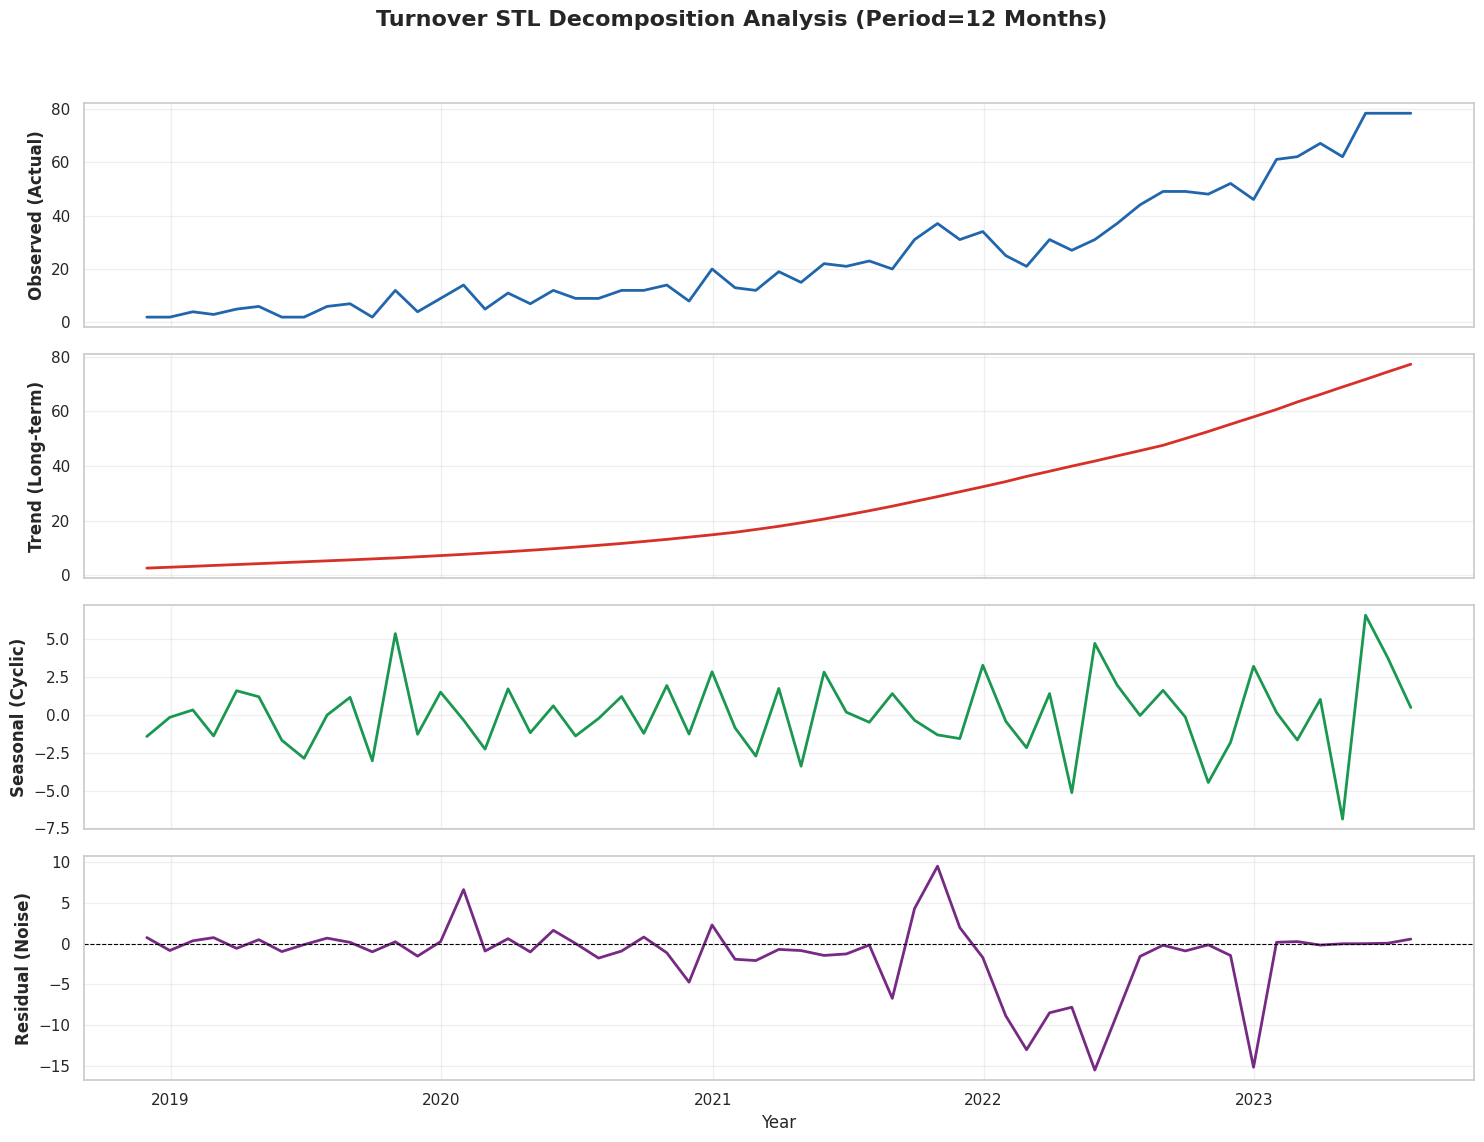

--- Decomposition Insights ---
Trend Strength    : 0.9588  (Closer to 1 = Predictable Trend)
Seasonal Strength : 0.1397  (Closer to 1 = Strong Yearly Cycle)


In [ ]:
# Seasonal Decomposition
PERIOD = 12

series_clean = ts_final[TARGET_COLUMN].asfreq(FREQ)

# STL Decomposition
stl    = STL(series_clean, period=PERIOD, robust=True)
result = stl.fit()

# Plot the four components
fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
fig.suptitle(f'Turnover STL Decomposition Analysis (Period={PERIOD} Months)',
             fontsize=16, fontweight='bold')

components = [
    ('Observed (Actual)',  result.observed,  '#2166ac'),
    ('Trend (Long-term)',  result.trend,     '#d73027'),
    ('Seasonal (Cyclic)',  result.seasonal,  '#1a9850'),
    ('Residual (Noise)',   result.resid,     '#762a83'),
]

for ax, (label, data, color) in zip(axes, components):
    ax.plot(data, color=color, linewidth=2)
    if label == 'Residual (Noise)':
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_ylabel(label, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Year')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Analysis of Strength
var_resid    = np.var(result.resid)
var_trend_r  = np.var(result.trend + result.resid)
var_season_r = np.var(result.seasonal + result.resid)

trend_strength    = max(0, 1 - var_resid / var_trend_r)
seasonal_strength = max(0, 1 - var_resid / var_season_r)

print(f"--- Decomposition Insights ---")
print(f"Trend Strength    : {trend_strength:.4f}  (Closer to 1 = Predictable Trend)")
print(f"Seasonal Strength : {seasonal_strength:.4f}  (Closer to 1 = Strong Yearly Cycle)")

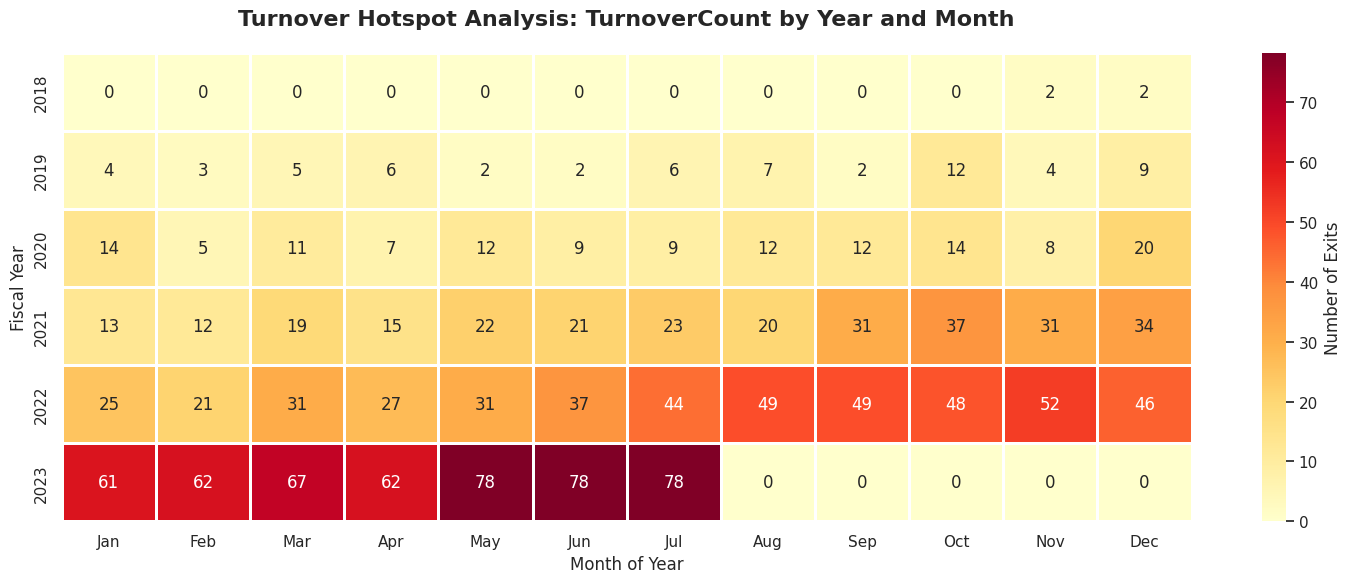

In [ ]:
# Seasonal Heatmap

hm = ts_final.copy()
hm['year']       = hm.index.year
hm['sub_period'] = hm.index.month


pivot = hm.pivot_table(values=TARGET_COLUMN,
                       index='year',
                       columns='sub_period',
                       aggfunc='sum').fillna(0)

month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
pivot.columns = [month_names[c] for c in pivot.columns]

plt.figure(figsize=(15, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=1, linecolor='white',
            cbar_kws={'label': 'Number of Exits'})

plt.title(f'Turnover Hotspot Analysis: {TARGET_COLUMN} by Year and Month',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Month of Year', fontsize=12)
plt.ylabel('Fiscal Year', fontsize=12)
plt.tight_layout()
plt.show()

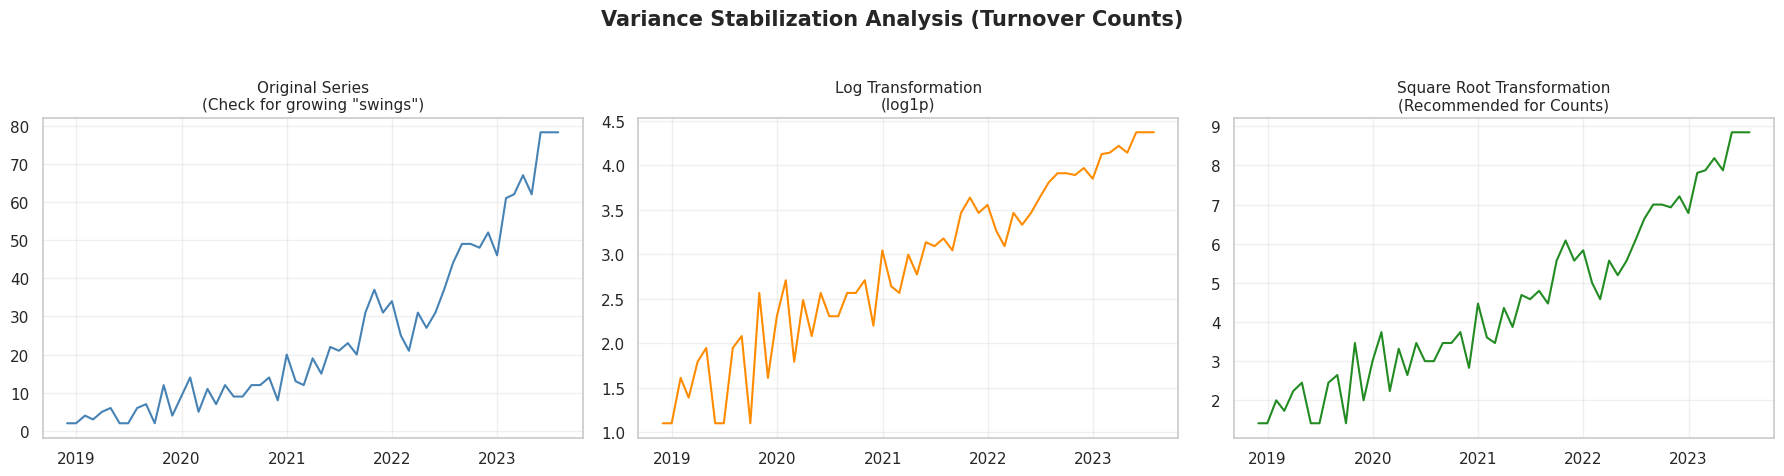

Transformation Type : None
Min Value Post-Trans: 1.4142
Max Value Post-Trans: 8.8459


In [ ]:
# Variance Stabilization

orig = series_clean.copy()

# 1. Visualization of Options
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Variance Stabilization Analysis (Turnover Counts)', fontsize=15, fontweight='bold')

# Original Series
axes[0].plot(orig, color='steelblue', linewidth=1.5)
axes[0].set_title('Original Series\n(Check for growing "swings")', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Log Transformation

axes[1].plot(np.log1p(orig), color='darkorange', linewidth=1.5)
axes[1].set_title('Log Transformation\n(log1p)', fontsize=11)
axes[1].grid(True, alpha=0.3)

# Square Root Transformation
axes[2].plot(np.sqrt(orig), color='forestgreen', linewidth=1.5)
axes[2].set_title('Square Root Transformation\n(Recommended for Counts)', fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

ts_model = np.sqrt(orig)

# Original look stable
TRANSFORMED = False

print(f"Transformation Type : {'Square Root' if TRANSFORMED else 'None'}")
print(f"Min Value Post-Trans: {ts_model.min():.4f}")
print(f"Max Value Post-Trans: {ts_model.max():.4f}")

In [ ]:
def adf_kpss_test(series, label='Series'):
    """Run ADF and KPSS tests and print a combined interpretation."""
    s = series.dropna()

    # ADF Test
    adf_stat, adf_p, adf_lags, adf_nobs, adf_cv, _ = adfuller(s, autolag='AIC')

    # KPSS Test
    kpss_stat, kpss_p, kpss_lags, kpss_cv = kpss(s, regression='c', nlags='auto')

    print(f"\n{'═'*60}")
    print(f"  STATIONARITY TESTS: {label}")
    print(f"{'═'*60}")
    print(f"  {'Test':<22} {'Statistic':>12} {'p-value':>10} {'Verdict':>20}")
    print(f"  {'─'*58}")

    adf_verdict  = '✅ STATIONARY'   if adf_p  < 0.05 else '❌ NON-STATIONARY'
    kpss_verdict = '✅ STATIONARY'   if kpss_p > 0.05 else '❌ NON-STATIONARY'

    print(f"  {'ADF (H0: unit root)':<22} {adf_stat:>12.4f} {adf_p:>10.4f} {adf_verdict:>20}")
    print(f"  {'KPSS (H0: stationary)':<22} {kpss_stat:>12.4f} {kpss_p:>10.4f} {kpss_verdict:>20}")

    print(f"\n  ADF Critical Values : 1%={adf_cv['1%']:.3f}  5%={adf_cv['5%']:.3f}  10%={adf_cv['10%']:.3f}")
    print(f"  KPSS Critical Values: 1%={kpss_cv['1%']:.3f}  5%={kpss_cv['5%']:.3f}  10%={kpss_cv['10%']:.3f}")

    # Consensus
    adf_stat_   = adf_p  < 0.05
    kpss_stat_  = kpss_p > 0.05
    print(f"\n  ┌─ CONSENSUS ───────────────────────────────────────┐")
    if adf_stat_ and kpss_stat_:
        print(f"  │  ✅ Both tests agree: STATIONARY                  │")
    elif not adf_stat_ and not kpss_stat_:
        print(f"  │  ❌ Both tests agree: NON-STATIONARY               │")
    elif adf_stat_ and not kpss_stat_:
        print(f"  │  ⚠️  Trend-stationary (possibly difference)        │")
    else:
        print(f"  │  ⚠️  Difference-stationary (possible unit root)    │")
    print(f"  └───────────────────────────────────────────────────┘")
    print(f"{'═'*60}")

    return {'adf_p': adf_p, 'kpss_p': kpss_p,
            'adf_stationary': adf_stat_, 'kpss_stationary': kpss_stat_}

print("Stationarity test function defined.")

Stationarity test function defined.


In [ ]:
# ── Test 1: Original (or transformed) series ─────────────────────────
r0 = adf_kpss_test(ts_model, label='Original / Transformed Series')

# ── Test 2: First difference ──────────────────────────────────────────
ts_diff1 = ts_model.diff(1)
r1 = adf_kpss_test(ts_diff1.dropna(), label='1st Difference (d=1)')

# ── Test 3: Seasonal difference (lag = PERIOD) ────────────────────────
ts_sdiff = ts_model.diff(PERIOD)
r_s = adf_kpss_test(ts_sdiff.dropna(), label=f'Seasonal Difference (lag={PERIOD})')

# ── Test 4: First + Seasonal difference ──────────────────────────────
ts_diff1s = ts_model.diff(PERIOD).diff(1)
r1s = adf_kpss_test(ts_diff1s.dropna(), label=f'1st + Seasonal Difference')


d = 0
D = 0

# Apply the identified differencing
if D > 0:
    ts_stationary = ts_model.diff(PERIOD)
else:
    ts_stationary = ts_model.copy()

if d > 0:
    ts_stationary = ts_stationary.diff(d)

ts_stationary = ts_stationary.dropna()

print(f"\nFinal differencing: d={d}, D={D}")
print(f"Stationary series length: {len(ts_stationary)}")


════════════════════════════════════════════════════════════
  STATIONARITY TESTS: Original / Transformed Series
════════════════════════════════════════════════════════════
  Test                      Statistic    p-value              Verdict
  ──────────────────────────────────────────────────────────
  ADF (H0: unit root)          2.0864     0.9988     ❌ NON-STATIONARY
  KPSS (H0: stationary)        1.2094     0.0100     ❌ NON-STATIONARY

  ADF Critical Values : 1%=-3.575  5%=-2.924  10%=-2.600
  KPSS Critical Values: 1%=0.739  5%=0.463  10%=0.347

  ┌─ CONSENSUS ───────────────────────────────────────┐
  │  ❌ Both tests agree: NON-STATIONARY               │
  └───────────────────────────────────────────────────┘
════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
  STATIONARITY TESTS: 1st Difference (d=1)
════════════════════════════════════════════════════════════
  Test                      Statistic    p-val

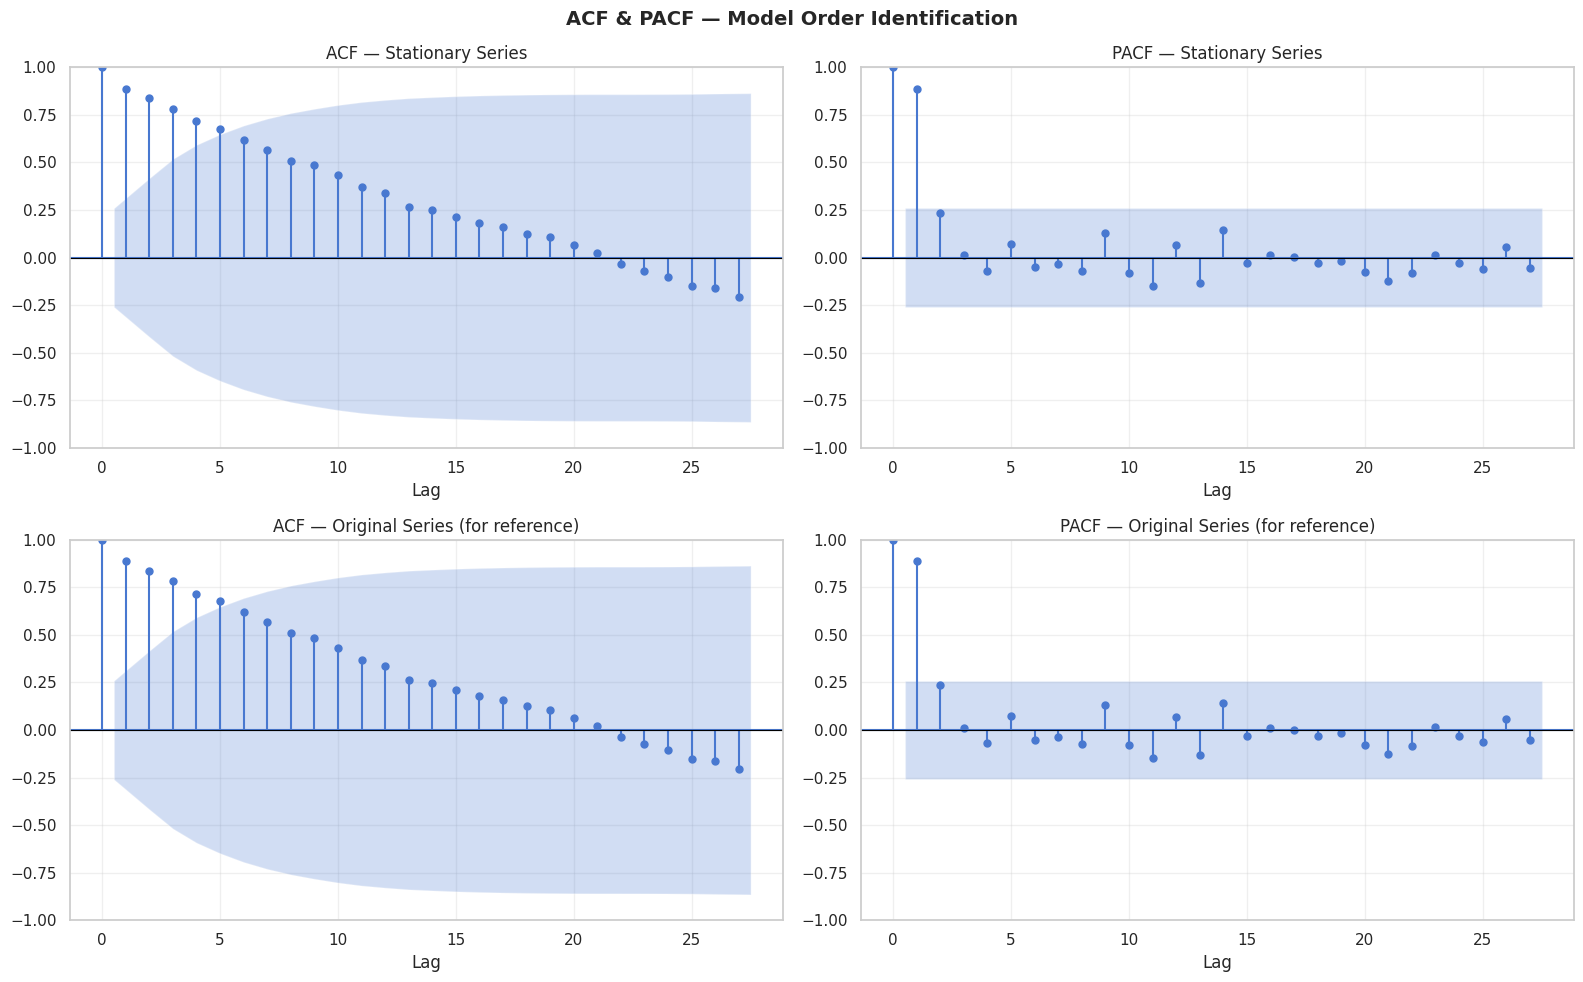


Significant lags (ACF):
Empty DataFrame
Columns: [Lag, ACF]
Index: []


In [ ]:
# ── ACF and PACF of the stationary series ────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('ACF & PACF — Model Order Identification', fontsize=14, fontweight='bold')

MAX_LAGS = min(3 * PERIOD, len(ts_stationary) // 2 - 1)

# ── Row 1: Stationary series ──────────────────────────────────────────
plot_acf( ts_stationary, lags=MAX_LAGS, ax=axes[0,0], alpha=0.05,
          title='ACF — Stationary Series')
plot_pacf(ts_stationary, lags=MAX_LAGS, ax=axes[0,1], alpha=0.05,
          method='ywm', title='PACF — Stationary Series')

# ── Row 2: Original (untransformed/undifferenced) series ─────────────
plot_acf( ts_model, lags=MAX_LAGS, ax=axes[1,0], alpha=0.05,
          title='ACF — Original Series (for reference)')
plot_pacf(ts_model, lags=MAX_LAGS, ax=axes[1,1], alpha=0.05,
          method='ywm', title='PACF — Original Series (for reference)')

for ax in axes.flat:
    ax.set_xlabel('Lag')
    ax.axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

# ── ACF / PACF value table (first 2 * PERIOD lags) ───────────────────
n_lags_table = min(2 * PERIOD, len(ts_stationary) // 2)
acf_vals  = acf( ts_stationary.dropna(), nlags=n_lags_table, alpha=0.05)
pacf_vals = pacf(ts_stationary.dropna(), nlags=n_lags_table, alpha=0.05, method='ywm')

acf_df = pd.DataFrame({
    'Lag' : range(n_lags_table + 1),
    'ACF' : acf_vals[0],
    'ACF_lower': acf_vals[1][:, 0] - acf_vals[0],
    'ACF_upper': acf_vals[1][:, 1] - acf_vals[0],
    'PACF': pacf_vals[0],
})
acf_df['ACF_sig']  = (acf_df['ACF_lower']  > 0) | (acf_df['ACF_upper'] < 0)
print("\nSignificant lags (ACF):")
print(acf_df[acf_df['ACF_sig'] & (acf_df['Lag'] > 0)][['Lag','ACF']].to_string(index=False))

Training : 2018-11-30 → 2023-03-31 (53 periods)
Test     : 2023-04-30 → 2023-07-31 (4 periods)


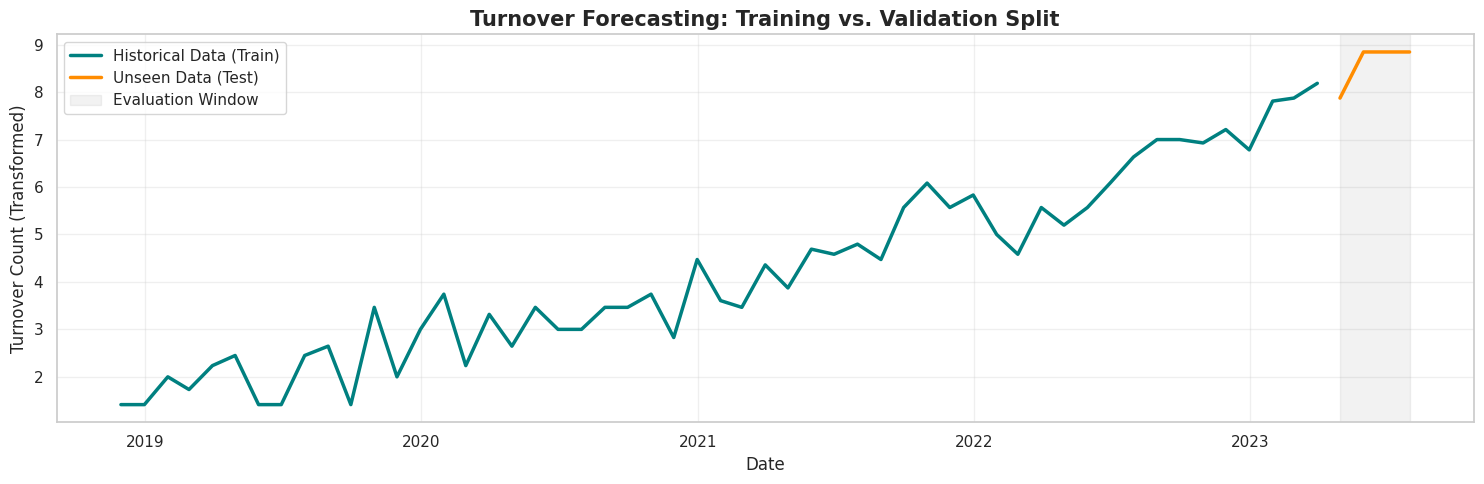

In [ ]:
# Train/Test Split

FORECAST_HORIZON = 4

train = ts_model.iloc[:-FORECAST_HORIZON]
test  = ts_model.iloc[-FORECAST_HORIZON:]

print(f"Training : {train.index.min().date()} → {train.index.max().date()} ({len(train)} periods)")
print(f"Test     : {test.index.min().date()} → {test.index.max().date()} ({len(test)} periods)")

plt.figure(figsize=(15, 5))

# Plotting
plt.plot(train.index, train.values, color='teal', linewidth=2.5, label='Historical Data (Train)')
plt.plot(test.index, test.values, color='darkorange', linewidth=2.5, label='Unseen Data (Test)')


plt.axvspan(test.index[0], test.index[-1], color='gray', alpha=0.1, label='Evaluation Window')

plt.title(f'Turnover Forecasting: Training vs. Validation Split', fontsize=15, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Turnover Count (Transformed)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Model Selection (AIC/BIC Grid Search)

# Use the d and D values identified before
D_val = D
d_val = d

p_range = range(0, 3)
q_range = range(0, 3)
P_range = range(0, 2)
Q_range = range(0, 2)

results_list = []

# Most efficient model selection
for p_val, q_val, P_val, Q_val in itertools.product(p_range, q_range, P_range, Q_range):
    try:
        model = SARIMAX(
            train,
            order=(p_val, d_val, q_val),
            seasonal_order=(P_val, D_val, Q_val, PERIOD),
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)

        results_list.append({
            'p': p_val, 'd': d_val, 'q': q_val,
            'P': P_val, 'D': D_val, 'Q': Q_val,
            'AIC': model.aic,
            'BIC': model.bic
        })
    except:
        continue

grid_df = pd.DataFrame(results_list).sort_values('AIC').reset_index(drop=True)

# Final Parameters
best_row = grid_df.iloc[0]
best_order = (int(best_row.p), int(best_row.d), int(best_row.q))
best_seasonal = (int(best_row.P), int(best_row.D), int(best_row.Q), PERIOD)

print(f"🏆 Grid Search Winner: SARIMA{best_order}{best_seasonal}")
display(grid_df.head(5))

🏆 Grid Search Winner: SARIMA(2, 0, 2)(0, 0, 1, 12)


,p,d,q,P,D,Q,AIC,BIC
0,2,0,2,0,0,1,64.551831,74.377348
1,1,0,1,0,0,1,64.691454,71.345700
2,1,0,2,0,0,1,66.030302,74.218233
3,1,0,1,1,0,0,66.454306,73.209824
4,2,0,1,0,0,1,66.599695,74.917503


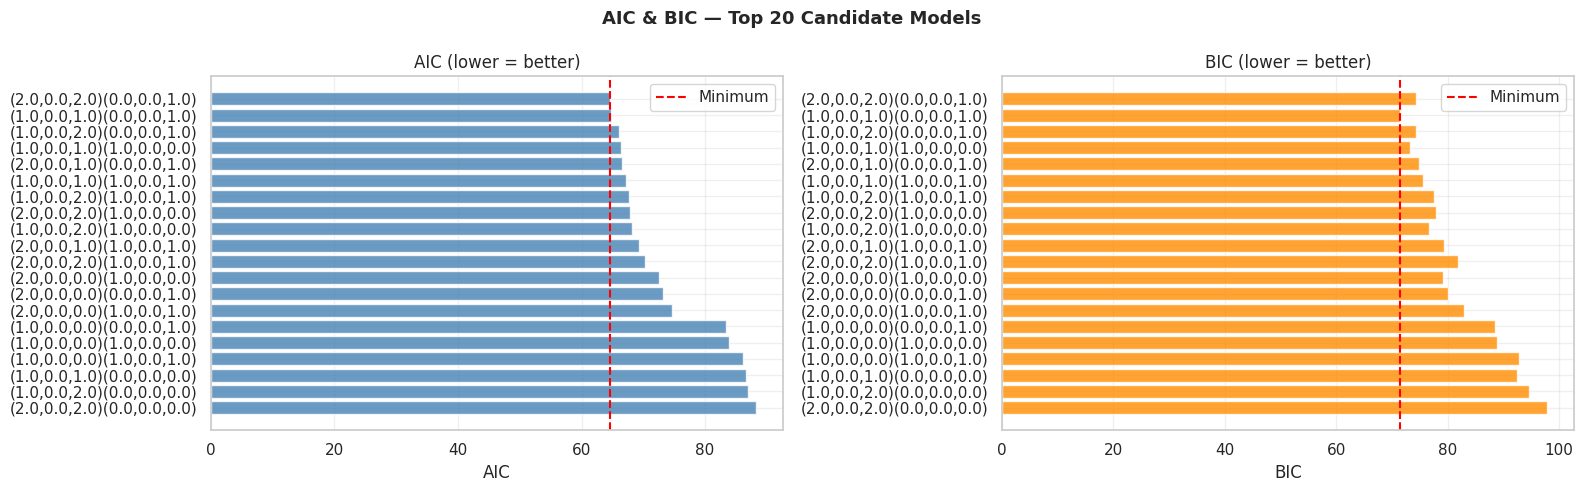

In [ ]:
# Visualize AIC and BIC across models
top_n = min(20, len(grid_df))
top_models = grid_df.head(top_n).copy()
top_models['Model'] = [f"({r.p},{r.d},{r.q})({r.P},{r.D},{r.Q})"
                        for _, r in top_models.iterrows()]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'AIC & BIC — Top {top_n} Candidate Models', fontsize=13, fontweight='bold')

axes[0].barh(top_models['Model'][::-1], top_models['AIC'][::-1], color='steelblue', alpha=0.8)
axes[0].set_title('AIC (lower = better)')
axes[0].set_xlabel('AIC')
axes[0].axvline(top_models['AIC'].min(), color='red', linestyle='--', label='Minimum')
axes[0].legend()

axes[1].barh(top_models['Model'][::-1], top_models['BIC'][::-1], color='darkorange', alpha=0.8)
axes[1].set_title('BIC (lower = better)')
axes[1].set_xlabel('BIC')
axes[1].axvline(top_models['BIC'].min(), color='red', linestyle='--', label='Minimum')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Fit Selected Model

BEST_ORDER           = (2, 0, 2)
BEST_SEASONAL_ORDER  = (0, 0, 1, 12) # PERIOD is 12 for Monthly data

final_model = SARIMAX(
    train,
    order=BEST_ORDER,
    seasonal_order=BEST_SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_result = final_model.fit(disp=False)

# Statistical summary
print(final_result.summary())

                                      SARIMAX Results                                       
Dep. Variable:                        TurnoverCount   No. Observations:                   53
Model:             SARIMAX(2, 0, 2)x(0, 0, [1], 12)   Log Likelihood                 -26.276
Date:                              Wed, 13 May 2026   AIC                             64.552
Time:                                      08:24:28   BIC                             74.377
Sample:                                  11-30-2018   HQIC                            68.048
                                       - 03-31-2023                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2932      0.180      1.630      0.103      -0.059       0.646
ar.L2          0.75

In [ ]:
# Key Model Statistics
print("=" * 65)
print("             KEY MODEL DIAGNOSTICS & COEFFICIENTS")
print("=" * 65)
print(f"  Model AIC      : {final_result.aic:.3f}")
print(f"  Model BIC      : {final_result.bic:.3f}")
print(f"  Log-Likelihood : {final_result.llf:.3f}")

coef_df = pd.DataFrame({
    'Parameter': final_result.params.index,
    'Estimate': final_result.params.values,
    'Std Error': final_result.bse.values,
    'p-value': final_result.pvalues.values
})

coef_df['Significance'] = coef_df['p-value'].apply(
    lambda x: '✅ Significant' if x < 0.05 else '❌ Not Significant'
)

print("\n--- Model Coefficient Breakdown ---")
print(coef_df.set_index('Parameter').round(4).to_string())

sig_params = coef_df[coef_df['p-value'] < 0.05]['Parameter'].tolist()
print("\n--- Strategic Interpretation ---")
if len(sig_params) > 0:
    print(f"The model is primarily driven by: {', '.join(sig_params)}")
else:
    print("Warning: No coefficients are statistically significant. Consider re-evaluating (p,d,q).")

             KEY MODEL DIAGNOSTICS & COEFFICIENTS
  Model AIC      : 64.552
  Model BIC      : 74.377
  Log-Likelihood : -26.276

--- Model Coefficient Breakdown ---
           Estimate  Std Error  p-value       Significance
Parameter                                                 
ar.L1        0.2932     0.1799   0.1031  ❌ Not Significant
ar.L2        0.7548     0.1850   0.0000      ✅ Significant
ma.L1       -0.1311   126.8942   0.9992  ❌ Not Significant
ma.L2       -0.8690   110.2645   0.9937  ❌ Not Significant
ma.S.L12     6.7688    12.0356   0.5738  ❌ Not Significant
sigma2       0.0046     0.5772   0.9936  ❌ Not Significant

--- Strategic Interpretation ---
The model is primarily driven by: ar.L2


In [ ]:
# Forecast Generation

forecast_obj  = final_result.get_forecast(steps=FORECAST_HORIZON)
forecast_mean_trans = forecast_obj.predicted_mean
conf_int_trans      = forecast_obj.conf_int(alpha=0.05)

# Align index with the test set
forecast_mean_trans.index = test.index
conf_int_trans.index      = test.index

# Back-Transform
if TRANSFORMED:
    forecast_final = np.square(forecast_mean_trans)
    lower_ci       = np.square(conf_int_trans.iloc[:, 0])
    upper_ci       = np.square(conf_int_trans.iloc[:, 1])
    test_actual    = np.square(test)
else:
    forecast_final = forecast_mean_trans
    test_actual    = test.copy()
    lower_ci       = conf_int_trans.iloc[:, 0]
    upper_ci       = conf_int_trans.iloc[:, 1]

# Forecast Performance Summary
forecast_summary = pd.DataFrame({
    'Actual_Exits': test_actual.values,
    'Predicted_Exits': forecast_final.values,
    'Lower_Bound': lower_ci.values,
    'Upper_Bound': upper_ci.values,
}, index=test.index)


forecast_summary['Within_CI'] = (
    (forecast_summary['Actual_Exits'] >= forecast_summary['Lower_Bound']) &
    (forecast_summary['Actual_Exits'] <= forecast_summary['Upper_Bound'])
)

print("="*65)
print(f"        FORECAST VS ACTUALS (Next {FORECAST_HORIZON} Months)")
print("="*65)
print(forecast_summary.round(2))

pct_within = forecast_summary['Within_CI'].mean() * 100
print(f"\nReliability Score: {pct_within:.1f}% of actuals fell within the 95% CI.")

        FORECAST VS ACTUALS (Next 4 Months)
            Actual_Exits  Predicted_Exits  Lower_Bound  Upper_Bound  Within_CI
2023-04-30          7.87             8.20         7.29         9.11       True
2023-05-31          8.85             8.25         7.33         9.18       True
2023-06-30          8.85             8.68         7.76         9.61       True
2023-07-31          8.85             8.87         7.94         9.80       True

Reliability Score: 100.0% of actuals fell within the 95% CI.


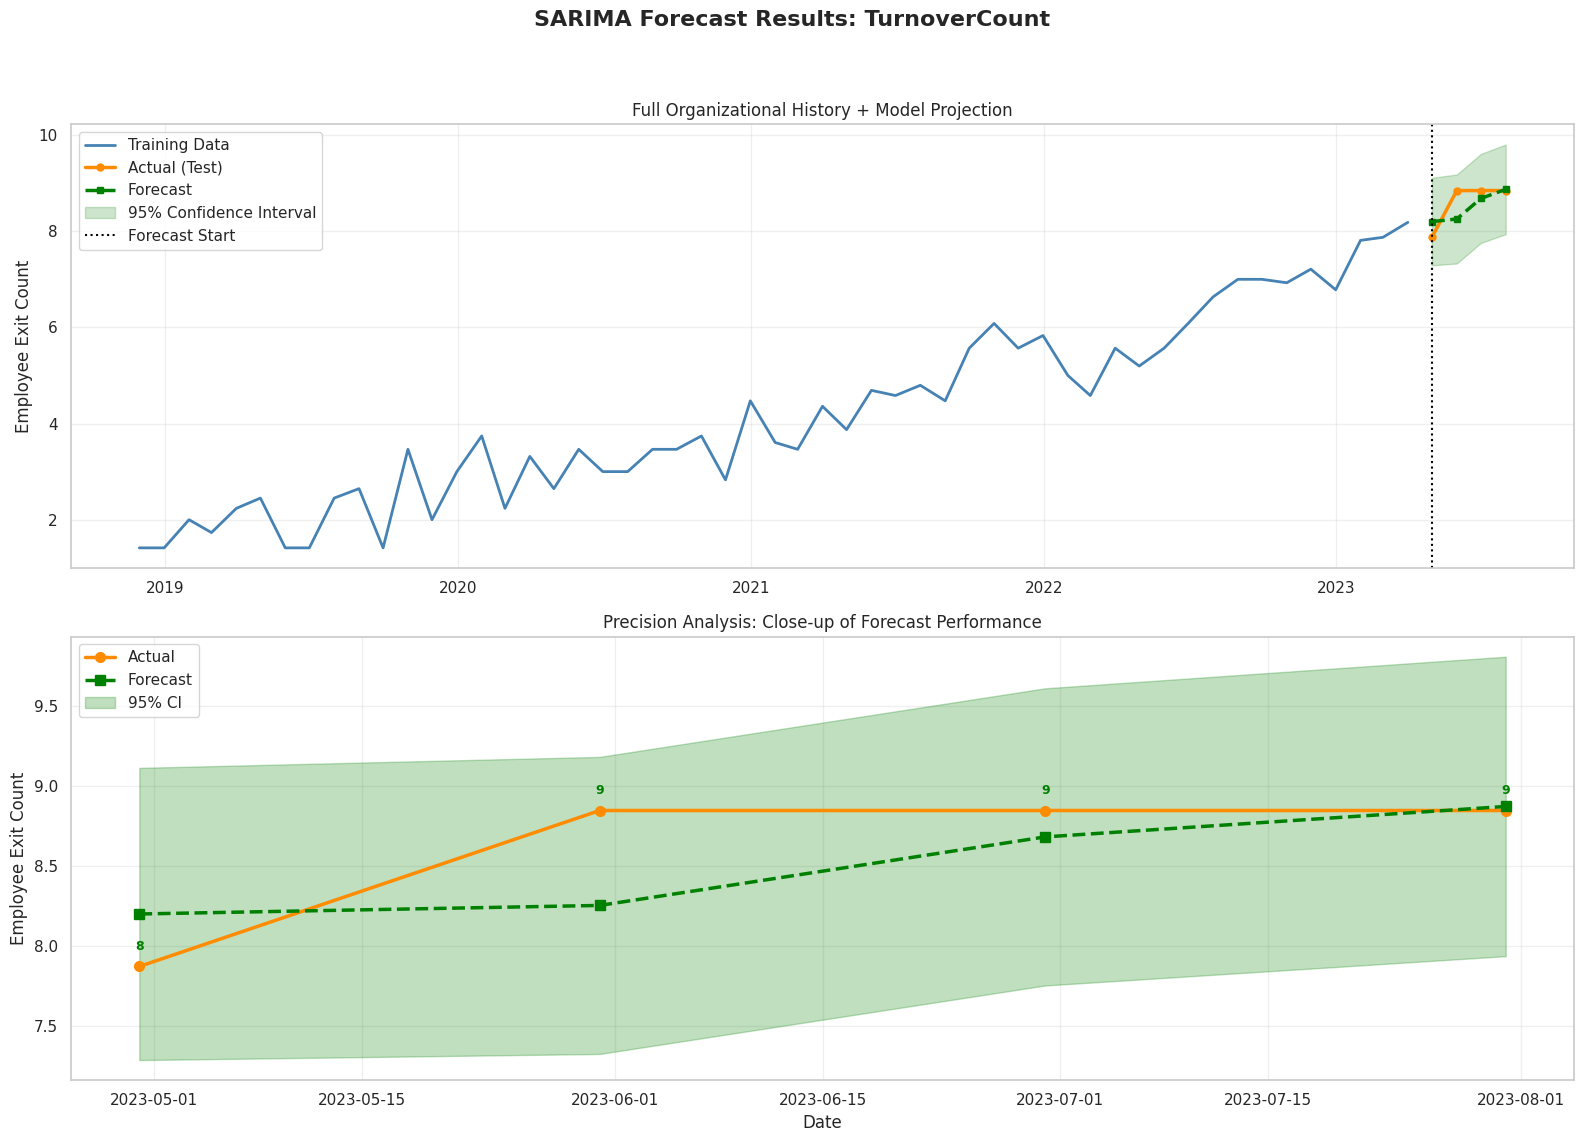

In [ ]:
# Forecast Visualization

forecast_mean = forecast_final

# Prepare historical data
if TRANSFORMED:
    train_plot = np.square(train)
else:
    train_plot = train.copy()

fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle(f'SARIMA Forecast Results: {TARGET_COLUMN}', fontsize=16, fontweight='bold')

# Plot 1: Full History + Forecast
axes[0].plot(train_plot, color='steelblue', linewidth=2, label='Training Data')
axes[0].plot(test_actual, color='darkorange', linewidth=2.5,
             marker='o', markersize=5, label='Actual (Test)')
axes[0].plot(forecast_mean, color='green', linewidth=2.5,
             linestyle='--', marker='s', markersize=5, label='Forecast')

# Use the back-transformed bounds from Phase 16
axes[0].fill_between(test.index, lower_ci, upper_ci,
                     alpha=0.2, color='green', label='95% Confidence Interval')

axes[0].axvline(x=test.index[0], color='black', linestyle=':',
                linewidth=1.5, label='Forecast Start')
axes[0].set_title('Full Organizational History + Model Projection')
axes[0].set_ylabel('Employee Exit Count')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# Plot 2: Zoomed Forecast Window
axes[1].plot(test_actual, color='darkorange', linewidth=2.5,
             marker='o', markersize=7, label='Actual')
axes[1].plot(forecast_mean, color='green', linewidth=2.5,
             linestyle='--', marker='s', markersize=7, label='Forecast')
axes[1].fill_between(test.index, lower_ci, upper_ci,
                     alpha=0.25, color='green', label='95% CI')

# Annotate values (Using the summary table we built in Phase 16/17)
for i, (idx, row) in enumerate(forecast_summary.iterrows()):
    # If actual fell within our predicted range, color it green; else red.
    color = 'green' if row['Within_CI'] else 'red'
    axes[1].annotate(f"{row['Actual_Exits']:.0f}",
                     xy=(idx, row['Actual_Exits']),
                     xytext=(0, 12), textcoords='offset points',
                     ha='center', fontsize=9, fontweight='bold', color=color)

axes[1].set_title('Precision Analysis: Close-up of Forecast Performance')
axes[1].set_ylabel('Employee Exit Count')
axes[1].set_xlabel('Date')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# Evaluation metrics

def smape(actual, forecast):
    """Symmetric Mean Absolute Percentage Error (0–200%)."""
    return 100 * np.mean(2 * np.abs(actual - forecast) /
                         (np.abs(actual) + np.abs(forecast) + 1e-9))

def mape(actual, forecast):
    """Mean Absolute Percentage Error."""
    return 100 * np.mean(np.abs((actual - forecast) / (actual + 1e-9)))

# Compute metrics
actual_vals   = test_actual.values
forecast_vals = forecast_mean.values

mae_val   = mean_absolute_error(actual_vals, forecast_vals)
rmse_val  = np.sqrt(mean_squared_error(actual_vals, forecast_vals))
mape_val  = mape(actual_vals, forecast_vals)
smape_val = smape(actual_vals, forecast_vals)

# Naive baseline: last observed value repeated
naive_forecast = np.full(FORECAST_HORIZON, train_plot.iloc[-1])
mae_naive  = mean_absolute_error(actual_vals, naive_forecast)
rmse_naive = np.sqrt(mean_squared_error(actual_vals, naive_forecast))

# Seasonal naïve: repeat same period from last cycle
seasonal_naive = train_plot.values[-PERIOD:] if len(train_plot) >= PERIOD else naive_forecast
seasonal_naive = np.tile(seasonal_naive, int(np.ceil(FORECAST_HORIZON / PERIOD)))[:FORECAST_HORIZON]
mae_snaive  = mean_absolute_error(actual_vals, seasonal_naive)
rmse_snaive = np.sqrt(mean_squared_error(actual_vals, seasonal_naive))

# Print comparison table
metrics_df = pd.DataFrame({
    'Model'  : ['SARIMA (Your Model)', 'Naïve Baseline', 'Seasonal Naïve'],
    'MAE'    : [mae_val, mae_naive, mae_snaive],
    'RMSE'   : [rmse_val, rmse_naive, rmse_snaive],
    'MAPE %' : [mape_val, mape(actual_vals, naive_forecast),
                mape(actual_vals, seasonal_naive)],
    'SMAPE %': [smape_val, smape(actual_vals, naive_forecast),
                smape(actual_vals, seasonal_naive)]
})
metrics_df = metrics_df.round(4)
print("\n" + "=" * 72)
print(" MODEL PERFORMANCE COMPARISON")
print("=" * 72)
print(metrics_df.to_string(index=False))
print("=" * 72)
print("\n📌 Lower values = better performance for all metrics.")
print("   MAPE > 100% or SMAPE > 100% indicates very poor fit.")

# Skill score (vs naive)
skill_mae  = 1 - mae_val  / mae_naive
skill_rmse = 1 - rmse_val / rmse_naive
print(f"\n  Skill Score (vs Naïve) — MAE : {skill_mae*100:.1f}% improvement")
print(f"  Skill Score (vs Naïve) — RMSE: {skill_rmse*100:.1f}% improvement")


 MODEL PERFORMANCE COMPARISON
              Model    MAE   RMSE  MAPE %  SMAPE %
SARIMA (Your Model) 0.2771 0.3480  3.2461   3.2870
     Naïve Baseline 0.5732 0.5929  6.5890   6.7870
     Seasonal Naïve 2.7329 2.7590 31.8292  38.0175

📌 Lower values = better performance for all metrics.
   MAPE > 100% or SMAPE > 100% indicates very poor fit.

  Skill Score (vs Naïve) — MAE : 51.7% improvement
  Skill Score (vs Naïve) — RMSE: 41.3% improvement


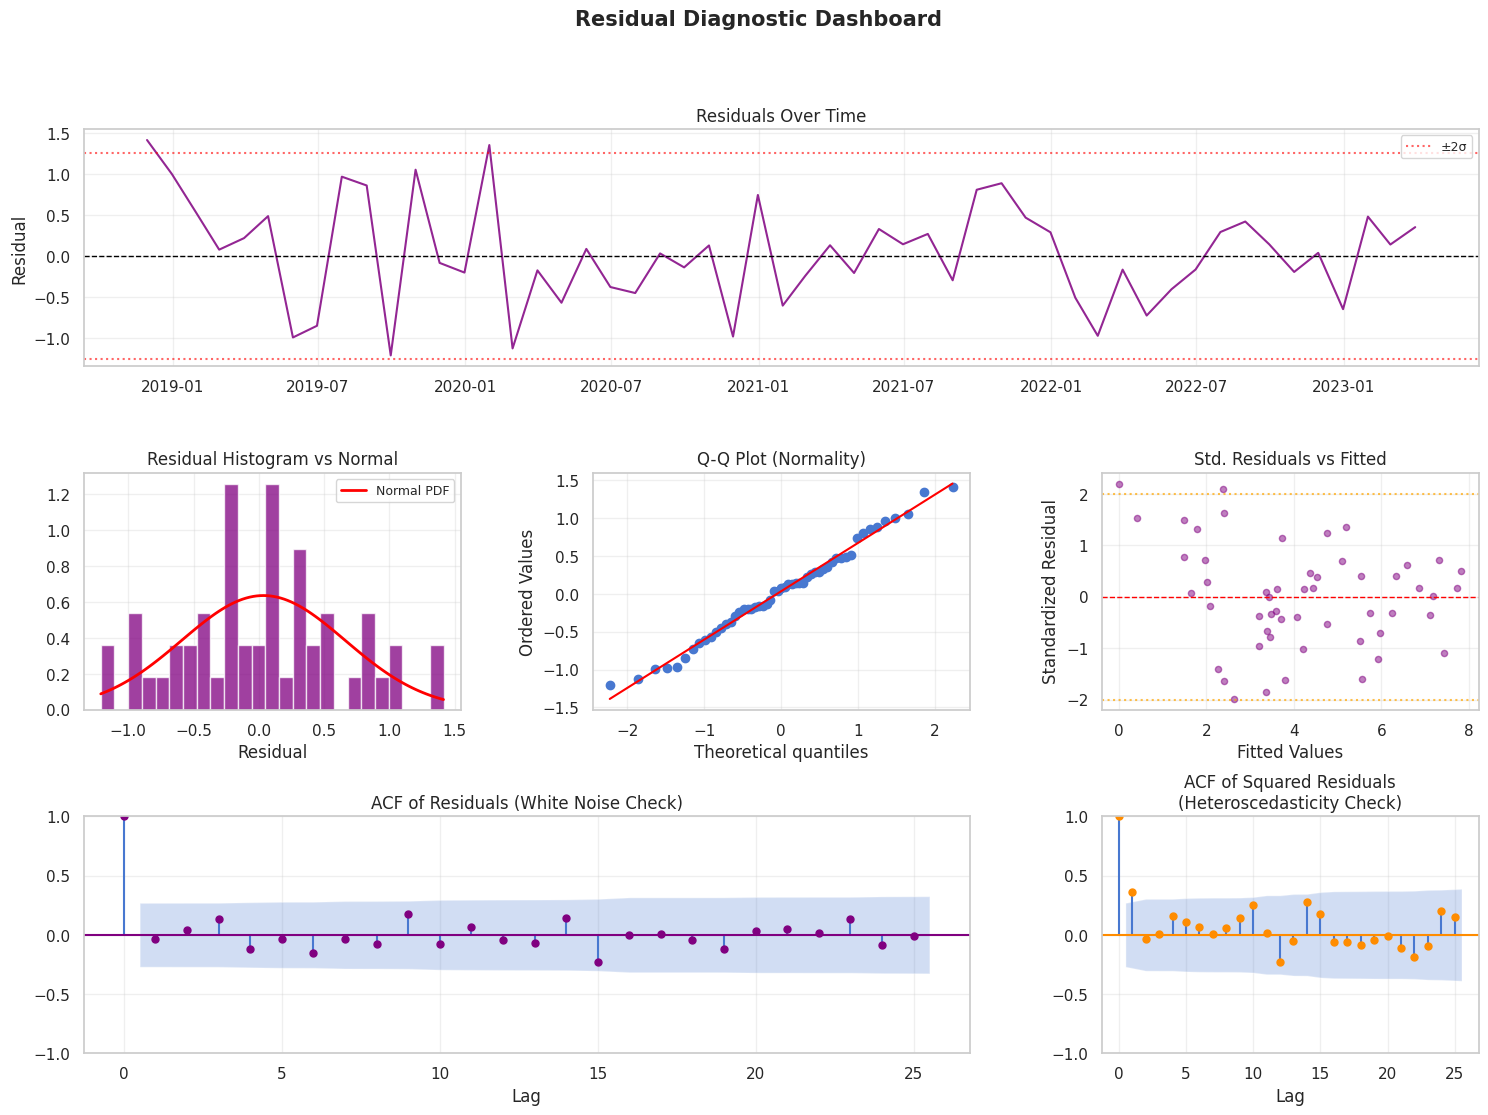

In [ ]:
# Residual Diagnostic Dashboard
# Extract residuals
residuals = final_result.resid

fig = plt.figure(figsize=(18, 12))
gs  = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('Residual Diagnostic Dashboard', fontsize=15, fontweight='bold')

# ── Plot 1: Residuals over time ───────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(residuals, color='purple', linewidth=1.5, alpha=0.85)
ax1.axhline(0, color='black', linestyle='--', linewidth=1)
ax1.axhline( 2 * residuals.std(), color='red', linestyle=':', alpha=0.6, label='±2σ')
ax1.axhline(-2 * residuals.std(), color='red', linestyle=':', alpha=0.6)
ax1.set_title('Residuals Over Time')
ax1.set_ylabel('Residual')
ax1.legend(fontsize=9)

# ── Plot 2: Residual histogram ────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(residuals, bins=25, color='purple', edgecolor='white', alpha=0.75, density=True)
x_range = np.linspace(residuals.min(), residuals.max(), 100)
ax2.plot(x_range, stats.norm.pdf(x_range, residuals.mean(), residuals.std()),
         color='red', linewidth=2, label='Normal PDF')
ax2.set_title('Residual Histogram vs Normal')
ax2.set_xlabel('Residual')
ax2.legend(fontsize=9)

# ── Plot 3: Q-Q Plot (normality check) ───────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
stats.probplot(residuals.dropna(), dist='norm', plot=ax3)
ax3.set_title('Q-Q Plot (Normality)')
ax3.get_lines()[1].set_color('red')

# ── Plot 4: Standardized residuals vs fitted ──────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
std_resid = (residuals - residuals.mean()) / residuals.std()
ax4.scatter(final_result.fittedvalues, std_resid, alpha=0.5, color='purple', s=20)
ax4.axhline(0, color='red', linestyle='--', linewidth=1)
ax4.axhline( 2, color='orange', linestyle=':', alpha=0.7)
ax4.axhline(-2, color='orange', linestyle=':', alpha=0.7)
ax4.set_title('Std. Residuals vs Fitted')
ax4.set_xlabel('Fitted Values')
ax4.set_ylabel('Standardized Residual')

# ── Plot 5: ACF of residuals (should be white noise) ──────────────────
ax5 = fig.add_subplot(gs[2, 0:2])
plot_acf(residuals.dropna(), lags=min(40, len(residuals)//2-1),
         ax=ax5, alpha=0.05, color='purple')
ax5.set_title('ACF of Residuals (White Noise Check)')
ax5.set_xlabel('Lag')

# ── Plot 6: Squared residuals ACF (volatility clustering check) ───────
ax6 = fig.add_subplot(gs[2, 2])
plot_acf(residuals.dropna()**2, lags=min(30, len(residuals)//2-1),
         ax=ax6, alpha=0.05, color='darkorange')
ax6.set_title('ACF of Squared Residuals\n(Heteroscedasticity Check)')
ax6.set_xlabel('Lag')

plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# FORMAL STATISTICAL TESTS ON RESIDUALS
# ═══════════════════════════════════════════════════════════════════

print("=" * 60)
print(" FORMAL RESIDUAL TESTS")
print("=" * 60)

# ── Test 1: Ljung-Box (autocorrelation in residuals) ─────────────────
lb_result = acorr_ljungbox(residuals.dropna(),
                           lags=[PERIOD, 2*PERIOD], return_df=True)
print("\n1. Ljung-Box Test (H0: No autocorrelation in residuals)")
print(lb_result)
for _, row in lb_result.iterrows():
    verdict = "✅ White noise" if row['lb_pvalue'] > 0.05 else "⚠️  Autocorrelation present"
    print(f"   Lag {int(row.name):>3}: p={row['lb_pvalue']:.4f} → {verdict}")

# ── Test 2: Shapiro-Wilk (normality of residuals) ────────────────────
# Use first 5000 observations (Shapiro-Wilk limit)
sw_sample = residuals.dropna().values[:5000]
sw_stat, sw_p = shapiro(sw_sample)
sw_verdict = "✅ Normal" if sw_p > 0.05 else "⚠️  Non-normal"
print(f"\n2. Shapiro-Wilk Test (H0: Residuals are normal)")
print(f"   Statistic={sw_stat:.4f}, p-value={sw_p:.4f} → {sw_verdict}")

# ── Test 3: D'Agostino-Pearson (normality, for larger samples) ───────
dp_stat, dp_p = normaltest(residuals.dropna().values)
dp_verdict = "✅ Normal" if dp_p > 0.05 else "⚠️  Non-normal"
print(f"\n3. D'Agostino-Pearson Test (H0: Residuals are normal)")
print(f"   Statistic={dp_stat:.4f}, p-value={dp_p:.4f} → {dp_verdict}")

# ── Residual summary statistics ───────────────────────────────────────
print(f"\n4. Residual Summary")
print(f"   Mean     : {residuals.mean():.6f}  (should be ≈ 0)")
print(f"   Std Dev  : {residuals.std():.4f}")
print(f"   Skewness : {residuals.skew():.4f}  (should be ≈ 0)")
print(f"   Kurtosis : {residuals.kurt():.4f}  (excess; should be ≈ 0)")

 FORMAL RESIDUAL TESTS

1. Ljung-Box Test (H0: No autocorrelation in residuals)
      lb_stat  lb_pvalue
12   6.952446   0.860740
24  16.817063   0.856359
   Lag  12: p=0.8607 → ✅ White noise
   Lag  24: p=0.8564 → ✅ White noise

2. Shapiro-Wilk Test (H0: Residuals are normal)
   Statistic=0.9858, p-value=0.7761 → ✅ Normal

3. D'Agostino-Pearson Test (H0: Residuals are normal)
   Statistic=0.2740, p-value=0.8720 → ✅ Normal

4. Residual Summary
   Mean     : 0.035344  (should be ≈ 0)
   Std Dev  : 0.6267
   Skewness : 0.0878  (should be ≈ 0)
   Kurtosis : -0.3450  (excess; should be ≈ 0)


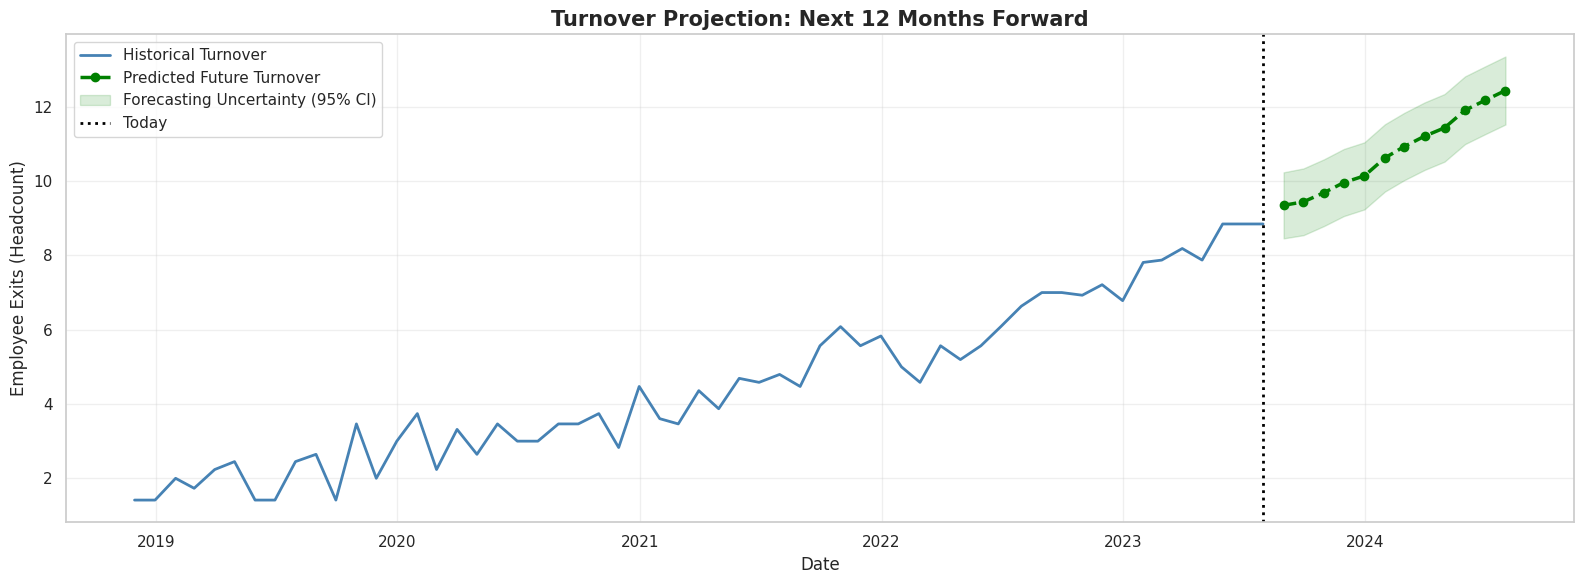


--- 12-Month HR Strategy Planning Table ---
            Projected_Exits  Min_Expected  Max_Expected
2023-08-31              9.3           8.5          10.2
2023-09-30              9.4           8.5          10.3
2023-10-31              9.7           8.8          10.6
2023-11-30             10.0           9.1          10.9
2023-12-31             10.1           9.2          11.0
2024-01-31             10.6           9.7          11.5
2024-02-29             10.9          10.0          11.8
2024-03-31             11.2          10.3          12.1
2024-04-30             11.4          10.5          12.3
2024-05-31             11.9          11.0          12.8
2024-06-30             12.2          11.3          13.1
2024-07-31             12.4          11.5          13.4


In [ ]:
# ── Phase 20: Final Refit & Forward Projection ───────────────────────

# 1. Refit on the ENTIRE dataset (ts_model) for maximum accuracy
full_model = SARIMAX(
    ts_model,
    order=BEST_ORDER,
    seasonal_order=BEST_SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# 2. Project 12 months into the future
FUTURE_HORIZON = 12
future_forecast = full_model.get_forecast(steps=FUTURE_HORIZON)
future_mean_trans = future_forecast.predicted_mean
future_ci_trans   = future_forecast.conf_int(alpha=0.05)

# 3. Back-Transform
if TRANSFORMED:
    future_mean = np.square(future_mean_trans)
    future_ci   = np.square(future_ci_trans)
    hist_plot   = np.square(ts_model)
else:
    future_mean = future_mean_trans
    future_ci   = future_ci_trans
    hist_plot   = ts_model.copy()

# 4. Final Visualization
plt.figure(figsize=(16, 6))
plt.plot(hist_plot, color='steelblue', linewidth=2, label='Historical Turnover')
plt.plot(future_mean, color='green', linewidth=2.5,
         linestyle='--', marker='o', markersize=6, label='Predicted Future Turnover')

plt.fill_between(future_mean.index,
                 future_ci.iloc[:,0], future_ci.iloc[:,1],
                 alpha=0.15, color='green', label='Forecasting Uncertainty (95% CI)')

plt.axvline(x=hist_plot.index[-1], color='black', linestyle=':', linewidth=2, label='Today')

plt.title(f'Turnover Projection: Next {FUTURE_HORIZON} Months Forward', fontsize=15, fontweight='bold')
plt.ylabel('Employee Exits (Headcount)')
plt.xlabel('Date')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Future Planning Table
future_df = pd.DataFrame({
    'Projected_Exits': future_mean,
    'Min_Expected': future_ci.iloc[:,0],
    'Max_Expected': future_ci.iloc[:,1]
})
print("\n--- 12-Month HR Strategy Planning Table ---")
print(future_df.round(1).to_string())